<a href="https://colab.research.google.com/github/boba-frog/Fraud-Detection/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
file_path = '/content/drive/MyDrive/DATASET/financial_fraud_detection_dataset.csv' # Replace with the actual path

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
DataFrame loaded successfully!
  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            online   Sydney         pos     False   
4    24.43         transfer         utilities  Toronto      mo

In [ ]:
#ENCODING PT1
#Configuring the variables for Machine Learning.
# Categorical columns identified from the previous step:
# ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']

# Plan for encoding categorical columns:
# transaction_id: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering if needed. For this task, we'll plan to drop it.
# timestamp: Time-series data. Requires specific handling (e.g., extracting features like hour, day of week). For this task, we'll plan to drop it for simplicity in this subtask.
# sender_account, receiver_account: High cardinality, likely not useful as direct features. Consider dropping or using feature engineering (e.g., aggregation). For this task, we'll plan to drop them.
# transaction_type: Low cardinality, nominal. Use one-hot encoding.
# merchant_category: Moderate cardinality, nominal. Use one-hot encoding.
# location: High cardinality. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_used: Moderate cardinality, nominal. Use one-hot encoding.
# is_fraud: Target variable (boolean). Can be treated as 0/1 for classification. No encoding needed for the target variable itself, but it's important to identify it.
# fraud_type: Moderate cardinality, nominal. Use one-hot encoding.
# payment_channel: Low cardinality, nominal. Use one-hot encoding.
# ip_address: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_hash: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.

# Columns to drop due to high cardinality or irrelevance for direct encoding:
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']

# Columns for one-hot encoding:
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']

# Target variable (no encoding needed for the variable itself):
target_col = 'is_fraud'

print("Plan for encoding categorical variables:")
print(f"Columns to be dropped: {cols_to_drop}")
print(f"Columns for one-hot encoding: {cols_for_onehot}")
print(f"Target variable: {target_col}")

Plan for encoding categorical variables:
Columns to be dropped: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']
Columns for one-hot encoding: ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']
Target variable: is_fraud


In [ ]:
#ENCODING PT2
# Converting USEFUL columns into usable data.
# Drop the columns identified for dropping
df_encoded = df.drop(columns=cols_to_drop)

# Apply one-hot encoding to the columns identified for one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=cols_for_onehot, drop_first=True)

# Display the first few rows of the encoded DataFrame to verify
print("DataFrame after dropping and one-hot encoding:")
display(df_encoded.head())

# Display the data types of the encoded DataFrame to verify
print("\nData types of the encoded DataFrame:")
print(df_encoded.dtypes)

DataFrame after dropping and one-hot encoding:


,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,transaction_type_payment,transaction_type_transfer,transaction_type_withdrawal,merchant_category_grocery,...,merchant_category_restaurant,merchant_category_retail,merchant_category_travel,merchant_category_utilities,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer
0,343.78,False,NaN,-0.21,3,0.22,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
1,419.65,False,NaN,-0.14,7,0.96,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,2773.86,False,NaN,-1.78,20,0.89,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,1666.22,False,NaN,-0.60,6,0.37,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,24.43,False,NaN,0.79,13,0.27,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False



Data types of the encoded DataFrame:
amount                           float64
is_fraud                            bool
time_since_last_transaction      float64
spending_deviation_score         float64
velocity_score                     int64
geo_anomaly_score                float64
transaction_type_payment            bool
transaction_type_transfer           bool
transaction_type_withdrawal         bool
merchant_category_grocery           bool
merchant_category_online            bool
merchant_category_other             bool
merchant_category_restaurant        bool
merchant_category_retail            bool
merchant_category_travel            bool
merchant_category_utilities         bool
device_used_mobile                  bool
device_used_pos                     bool
device_used_web                     bool
payment_channel_UPI                 bool
payment_channel_card                bool
payment_channel_wire_transfer       bool
dtype: object


In [ ]:
!pip install imbalanced-learn

Original dataset shape: Counter({False: 4820447, True: 179553})
Resampled dataset shape: Counter({False: 3856358, True: 385635})

Best threshold (Max F1) = 0.05
Average Precision (PR-AUC): 0.0435

Confusion Matrix:
[[221879 742210]
 [  2030  33881]]

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.23      0.37    964089
        True       0.04      0.94      0.08     35911

    accuracy                           0.26   1000000
   macro avg       0.52      0.59      0.23   1000000
weighted avg       0.96      0.26      0.36   1000000


Top 10 Feature Importances:
device_used_web: 0.1121
payment_channel_UPI: 0.1101
payment_channel_card: 0.1079
device_used_pos: 0.1046
device_used_mobile: 0.1002
payment_channel_wire_transfer: 0.0960
merchant_category_retail: 0.0448
merchant_category_grocery: 0.0431
merchant_category_restaurant: 0.0420
merchant_category_travel: 0.0419


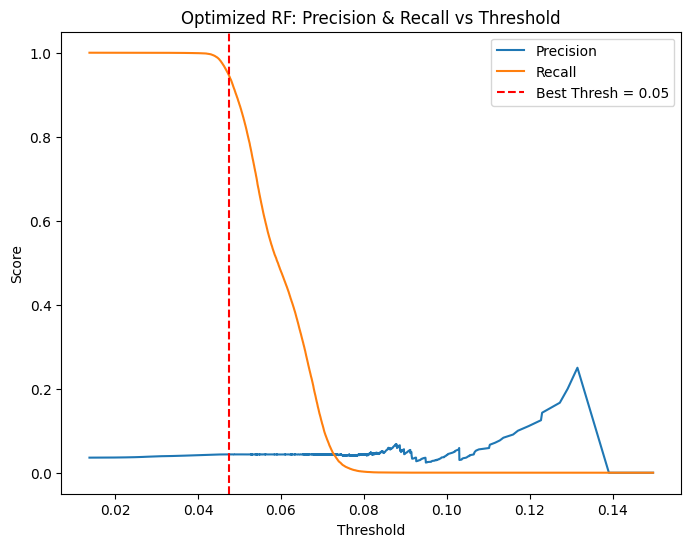

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Data prep
# -----------------------
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# Impute missing values
X['time_since_last_transaction'] = X['time_since_last_transaction'].fillna(
    X['time_since_last_transaction'].mean()
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# -----------------------
# Random Forest Training
# -----------------------
model = RandomForestClassifier(
    n_estimators=100,
    max_samples=0.1,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# Get probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# -----------------------
# Threshold Optimization
# -----------------------
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx = np.argmax(f1_scores)
best_thresh = np.append(thresholds_pr, 1)[best_idx]

# -----------------------
# Evaluation & Reporting
# -----------------------
results = [
    ("DEFAULT (Threshold = 0.5)", (y_proba >= 0.5).astype(int)),
    (f"OPTIMIZED (Threshold = {best_thresh:.2f})", (y_proba >= best_thresh).astype(int))
]

for title, y_pred in results:
    print("\n" + "="*40)
    print(title)
    print("="*40)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1 & 2. Confusion Matrices
for i, (title, y_pred) in enumerate(results):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0, i], cmap='Blues', colorbar=False)
    axes[0, i].set_title(f"Confusion Matrix: {title}")

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1, 0].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC)')
axes[1, 0].legend(loc="lower right")

# 4. Precision-Recall vs Threshold
axes[1, 1].plot(thresholds_pr, precision[:-1], label="Precision")
axes[1, 1].plot(thresholds_pr, recall[:-1], label="Recall")
axes[1, 1].axvline(best_thresh, color='red', linestyle='--', label=f"Best Thresh = {best_thresh:.2f}")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("Precision-Recall vs Threshold")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage Precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")